# Temporal Graph Clustering Performance Test

Focused test of the new TemporalGraphClusteringProcessor for high-performance neutron clustering.

**Goals:**
1. Test temporal graph clustering on TPX3 data
2. Compare performance with ABS clustering baseline
3. Validate statistical temporal batching approach
4. Measure M2 Max performance characteristics

**Data:** Ni powder sample - `Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3`

**Target Performance:** 50-100M hits/sec on M2 Max (vs current ~8.7M hits/sec ABS)

> NOTE: Running on M2 Max MacBook Pro with 32GB RAM - memory optimized for large dataset.

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 2.0.0
Numpy version: 2.3.1


## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "data/"
ni_file = "Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
   Size: 5652.0 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 24.14 seconds
✅ Total hits extracted: 736,028,562
✅ Processing rate: 30.5 M hits/second

Hit data structure:
  tof: uint32, shape (736028562,)
    range: 0 - 666656
  x: uint16, shape (736028562,)
    range: 0 - 513
  y: uint16, shape (736028562,)
    range: 0 - 513
  timestamp: uint32, shape (736028562,)
    range: 30348 - 1074755785
  tot: uint16, shape (736028562,)
    range: 1 - 807
  chip_id: uint8, shape (736028562,)
    range: 0 - 3
  cluster_id: int32, shape (736028562,)
    range: -1 - -1


## 4. Temporal Graph Clustering Configuration

In [4]:
print("=== Setting up temporal graph clustering configuration ===")

# Use VENUS defaults as starting point
config = tdc.ClusteringConfig.venus_defaults()

# Configure for temporal_graph algorithm
config.clustering_algorithm = "temporal_graph"

print("Temporal Graph clustering configuration:")
print(f"  Algorithm: {config.clustering_algorithm}")
print(f"  Peak fitting: {config.peak_fitting_algorithm}")
print(f"  Clustering enabled: {config.enable_clustering}")

print("\nTemporal Graph clustering parameters:")
print(f"  Spatial radius: {config.temporal_graph.graph_config.radius} pixels")
print(f"  Min cluster size: {config.temporal_graph.graph_config.min_cluster_size} hits")
print(
    f"  Time correlation window: {config.temporal_graph.graph_config.neutron_correlation_window} ns"
)
print(f"  Number of workers: {config.temporal_graph.num_workers} (0 = auto-detect)")
print(f"  Min batch size: {config.temporal_graph.min_batch_size} hits")
print(f"  Max batch size: {config.temporal_graph.max_batch_size} hits")
print(
    f"  Overlap factor: {config.temporal_graph.overlap_factor} (for 3σ boundary handling)"
)

print("\nCentroid fitting parameters:")
print(f"  Super resolution: {config.centroid.super_resolution_factor}x")
print(f"  TOT weighted: {config.centroid.weighted_by_tot}")
print(f"  Min TOT threshold: {config.centroid.min_tot_threshold}")


=== Setting up temporal graph clustering configuration ===
Temporal Graph clustering configuration:
  Algorithm: temporal_graph
  Peak fitting: centroid
  Clustering enabled: True

Temporal Graph clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 1 hits
  Time correlation window: 75.0 ns
  Number of workers: 0 (0 = auto-detect)
  Min batch size: 1000 hits
  Max batch size: 100000 hits
  Overlap factor: 3.0 (for 3σ boundary handling)

Centroid fitting parameters:
  Super resolution: 8.0x
  TOT weighted: True
  Min TOT threshold: 0.0


## 5. ABS Baseline Performance Test

In [5]:
print("=== ABS Clustering Baseline Performance ===")
print(f"Input: {len(hits):,} hits")

# Configure for ABS
abs_config = tdc.ClusteringConfig.venus_defaults()
abs_config.clustering_algorithm = "abs"

abs_start_time = time.time()

# Run ABS clustering
abs_neutron_view = tdc.cluster_hits_to_neutrons(hits, abs_config)
abs_neutrons = np.array(abs_neutron_view, copy=False)

abs_clustering_time = time.time() - abs_start_time

print(f"✅ ABS clustering completed in {abs_clustering_time:.2f} seconds")
print(f"✅ Output neutrons: {len(abs_neutrons):,}")
print(
    f"✅ ABS clustering rate: {len(hits) / abs_clustering_time / 1e6:.1f} M hits/second"
)

# Calculate clustering efficiency
abs_efficiency = len(abs_neutrons) / len(hits)
print(
    f"✅ ABS neutron extraction efficiency: {abs_efficiency:.6f} ({abs_efficiency * 100:.4f}%)"
)

=== ABS Clustering Baseline Performance ===
Input: 736,028,562 hits
✅ ABS clustering completed in 105.55 seconds
✅ Output neutrons: 295,086,437
✅ ABS clustering rate: 7.0 M hits/second
✅ ABS neutron extraction efficiency: 0.400917 (40.0917%)


## 6. Temporal Graph Clustering Performance Test


In [6]:
print("=== Temporal Graph Clustering Performance ===")
print(f"Input: {len(hits):,} hits")

temporal_start_time = time.time()

# Run temporal graph clustering
temporal_neutron_view = tdc.cluster_hits_to_neutrons(hits, config)
temporal_neutrons = np.array(temporal_neutron_view, copy=False)

temporal_clustering_time = time.time() - temporal_start_time

print(
    f"✅ Temporal graph clustering completed in {temporal_clustering_time:.2f} seconds"
)
print(f"✅ Output neutrons: {len(temporal_neutrons):,}")
print(
    f"✅ Temporal graph clustering rate: {len(hits) / temporal_clustering_time / 1e6:.1f} M hits/second"
)

# Calculate clustering efficiency
temporal_efficiency = len(temporal_neutrons) / len(hits)
print(
    f"✅ Temporal graph neutron extraction efficiency: {temporal_efficiency:.6f} ({temporal_efficiency * 100:.4f}%)"
)

# Performance comparison
speedup = abs_clustering_time / temporal_clustering_time
print(f"\n=== Performance Comparison ===")
print(
    f"ABS clustering:           {len(hits) / abs_clustering_time / 1e6:.1f} M hits/second"
)
print(
    f"Temporal graph clustering: {len(hits) / temporal_clustering_time / 1e6:.1f} M hits/second"
)
print(f"Speedup: {speedup:.1f}x {'FASTER' if speedup > 1 else 'SLOWER'}")
print(
    f"Target achieved: {'✅ YES' if len(hits) / temporal_clustering_time / 1e6 >= 50 else '❌ NO'} (target: 50+ M hits/sec)"
)

=== Temporal Graph Clustering Performance ===
Input: 736,028,562 hits
✅ Temporal graph clustering completed in 654.12 seconds
✅ Output neutrons: 247,447,251
✅ Temporal graph clustering rate: 1.1 M hits/second
✅ Temporal graph neutron extraction efficiency: 0.336192 (33.6192%)

=== Performance Comparison ===
ABS clustering:           7.0 M hits/second
Temporal graph clustering: 1.1 M hits/second
Speedup: 0.2x SLOWER
Target achieved: ❌ NO (target: 50+ M hits/sec)


## 7. Clustering Results Comparison

In [7]:
print("=== Clustering Results Comparison ===")

# ABS results analysis
abs_n_hits = abs_neutrons["n_hits"]
abs_single_hit = np.sum(abs_n_hits == 1)
abs_multi_hit = len(abs_neutrons) - abs_single_hit

print(f"\nABS Clustering Results:")
print(f"  Total neutrons: {len(abs_neutrons):,}")
print(
    f"  Single-hit neutrons: {abs_single_hit:,} ({100 * abs_single_hit / len(abs_neutrons):.1f}%)"
)
print(
    f"  Multi-hit neutrons: {abs_multi_hit:,} ({100 * abs_multi_hit / len(abs_neutrons):.1f}%)"
)
print(f"  Mean cluster size: {abs_n_hits.mean():.2f} hits")
print(f"  Max cluster size: {abs_n_hits.max()} hits")

# Temporal graph results analysis
temporal_n_hits = temporal_neutrons["n_hits"]
temporal_single_hit = np.sum(temporal_n_hits == 1)
temporal_multi_hit = len(temporal_neutrons) - temporal_single_hit

print(f"\nTemporal Graph Clustering Results:")
print(f"  Total neutrons: {len(temporal_neutrons):,}")
print(
    f"  Single-hit neutrons: {temporal_single_hit:,} ({100 * temporal_single_hit / len(temporal_neutrons):.1f}%)"
)
print(
    f"  Multi-hit neutrons: {temporal_multi_hit:,} ({100 * temporal_multi_hit / len(temporal_neutrons):.1f}%)"
)
print(f"  Mean cluster size: {temporal_n_hits.mean():.2f} hits")
print(f"  Max cluster size: {temporal_n_hits.max()} hits")

# Difference analysis
neutron_diff = len(temporal_neutrons) - len(abs_neutrons)
efficiency_diff = temporal_efficiency - abs_efficiency

print(f"\n=== Results Comparison ===")
print(
    f"Neutron count difference: {neutron_diff:+,} ({100 * neutron_diff / len(abs_neutrons):+.2f}%)"
)
print(
    f"Efficiency difference: {efficiency_diff:+.6f} ({efficiency_diff * 100:+.4f} percentage points)"
)
print(
    f"Mean cluster size difference: {temporal_n_hits.mean() - abs_n_hits.mean():+.2f} hits"
)


=== Clustering Results Comparison ===

ABS Clustering Results:
  Total neutrons: 295,086,437
  Single-hit neutrons: 106,340,741 (36.0%)
  Multi-hit neutrons: 188,745,696 (64.0%)
  Mean cluster size: 2.49 hits
  Max cluster size: 85 hits

Temporal Graph Clustering Results:
  Total neutrons: 247,447,251
  Single-hit neutrons: 79,269,321 (32.0%)
  Multi-hit neutrons: 168,177,930 (68.0%)
  Mean cluster size: 2.66 hits
  Max cluster size: 87 hits

=== Results Comparison ===
Neutron count difference: -47,639,186 (-16.14%)
Efficiency difference: -0.064725 (-6.4725 percentage points)
Mean cluster size difference: +0.17 hits


## 8. Cluster Size Distribution Comparison


=== Cluster Size Distribution Analysis ===


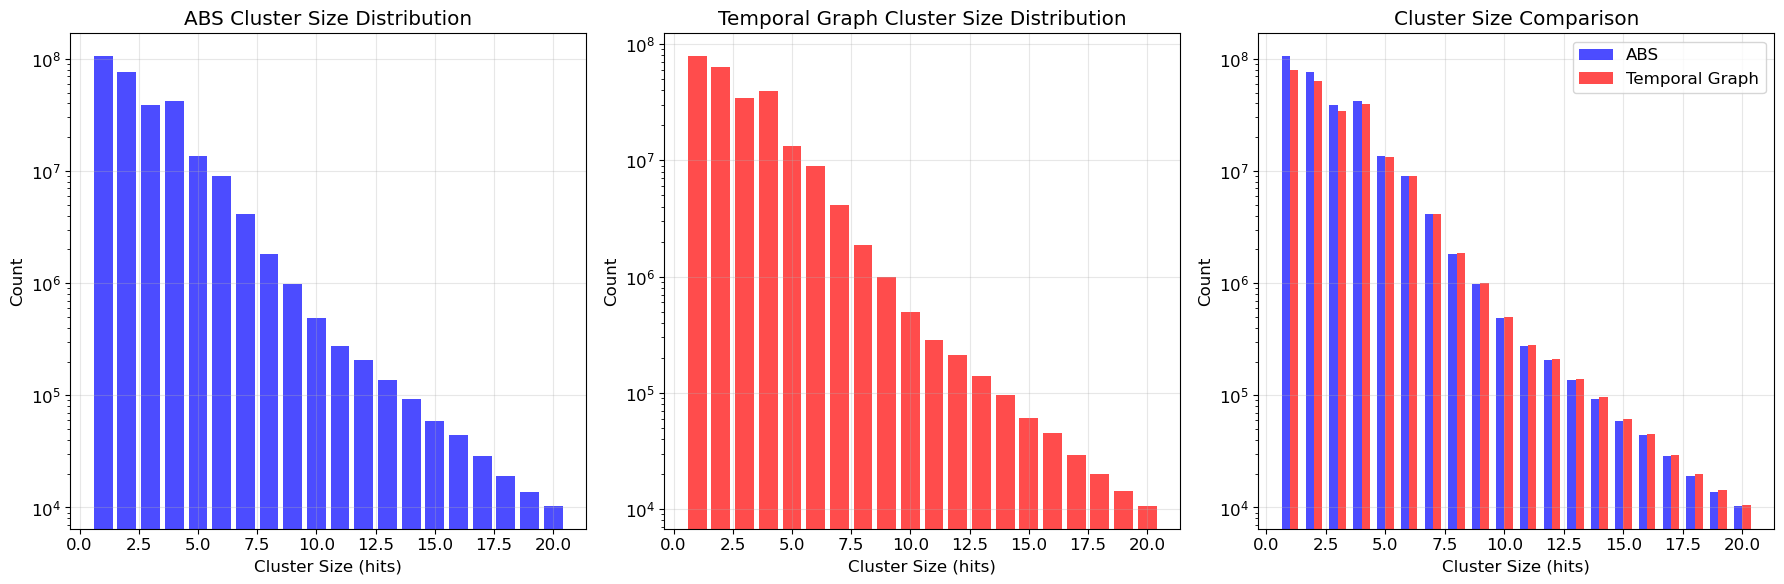


Detailed cluster size comparison (first 10 sizes):
Size |    ABS Count    | Temporal Count |   Difference
-----|-----------------|----------------|-------------
   1 |    106,340,741 |    79,269,321 | -27,071,420
   2 |     77,048,958 |    63,430,820 | -13,618,138
   3 |     38,621,572 |    34,287,167 |  -4,334,405
   4 |     42,291,226 |    39,843,342 |  -2,447,884
   5 |     13,512,266 |    13,228,119 |    -284,147
   6 |      8,955,944 |     8,935,619 |     -20,325
   7 |      4,096,635 |     4,147,080 |     +50,445
   8 |      1,837,790 |     1,868,897 |     +31,107
   9 |        973,205 |       994,319 |     +21,114
  10 |        489,263 |       499,325 |     +10,062


In [8]:
print("=== Cluster Size Distribution Analysis ===")

# Create cluster size histograms
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ABS cluster size distribution
abs_cluster_sizes, abs_counts = np.unique(abs_n_hits, return_counts=True)
ax1.bar(abs_cluster_sizes[:20], abs_counts[:20], alpha=0.7, color="blue")
ax1.set_xlabel("Cluster Size (hits)")
ax1.set_ylabel("Count")
ax1.set_title("ABS Cluster Size Distribution")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

# Temporal graph cluster size distribution
temporal_cluster_sizes, temporal_counts = np.unique(temporal_n_hits, return_counts=True)
ax2.bar(temporal_cluster_sizes[:20], temporal_counts[:20], alpha=0.7, color="red")
ax2.set_xlabel("Cluster Size (hits)")
ax2.set_ylabel("Count")
ax2.set_title("Temporal Graph Cluster Size Distribution")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

# Side-by-side comparison for first 10 cluster sizes
max_size = min(20, max(len(abs_cluster_sizes), len(temporal_cluster_sizes)))
x_pos = np.arange(1, max_size + 1)

# Align counts arrays
abs_aligned = np.zeros(max_size)
temporal_aligned = np.zeros(max_size)

for i, size in enumerate(abs_cluster_sizes[:max_size]):
    if size <= max_size:
        abs_aligned[size - 1] = abs_counts[i]

for i, size in enumerate(temporal_cluster_sizes[:max_size]):
    if size <= max_size:
        temporal_aligned[size - 1] = temporal_counts[i]

width = 0.35
ax3.bar(x_pos - width / 2, abs_aligned, width, label="ABS", alpha=0.7, color="blue")
ax3.bar(
    x_pos + width / 2,
    temporal_aligned,
    width,
    label="Temporal Graph",
    alpha=0.7,
    color="red",
)
ax3.set_xlabel("Cluster Size (hits)")
ax3.set_ylabel("Count")
ax3.set_title("Cluster Size Comparison")
ax3.set_yscale("log")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed comparison for first 10 sizes
print("\nDetailed cluster size comparison (first 10 sizes):")
print("Size |    ABS Count    | Temporal Count |   Difference")
print("-----|-----------------|----------------|-------------")
for size in range(1, 11):
    abs_count = (
        abs_counts[abs_cluster_sizes == size][0] if size in abs_cluster_sizes else 0
    )
    temporal_count = (
        temporal_counts[temporal_cluster_sizes == size][0]
        if size in temporal_cluster_sizes
        else 0
    )
    diff = temporal_count - abs_count
    print(f"{size:4} | {abs_count:14,} | {temporal_count:13,} | {diff:+11,}")

## 9. Spatial Distribution Comparison

=== Spatial Distribution Comparison ===


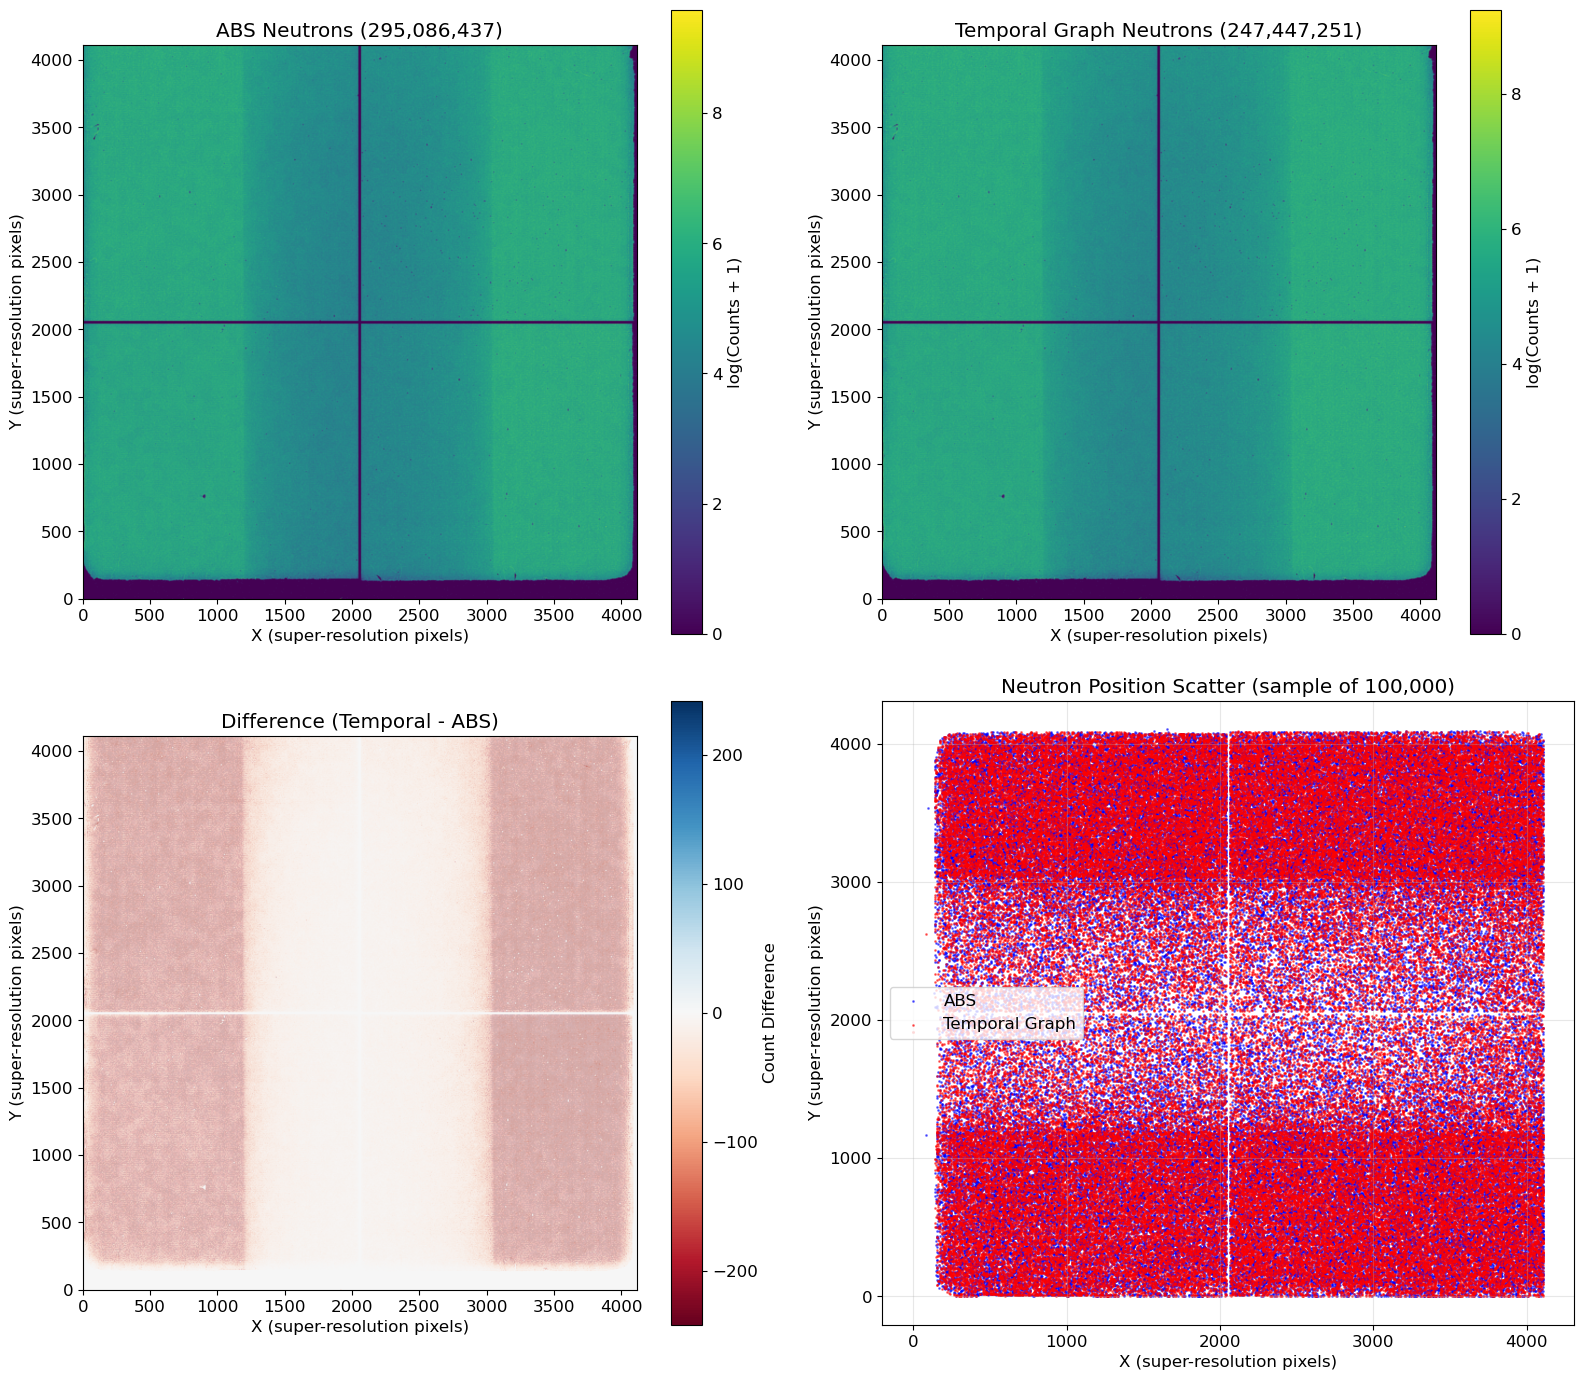


Spatial distribution statistics:
ABS neutrons - X range: 0.0 - 4104.0
ABS neutrons - Y range: 0.0 - 4104.0
Temporal neutrons - X range: 0.0 - 4104.0
Temporal neutrons - Y range: 0.0 - 4104.0


In [9]:
print("=== Spatial Distribution Comparison ===")

# Get detector configuration
det_config = tdc.DetectorConfig.venus_defaults()
DETECTOR_PIXELS = det_config.get_chip_size_x() * 2 + 2
NEUTRON_SUPER_RES = config.centroid.super_resolution_factor
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 14))

# ABS neutrons spatial distribution
abs_x = abs_neutrons["x"]
abs_y = abs_neutrons["y"]

hist_abs, _, _ = np.histogram2d(
    abs_x,
    abs_y,
    bins=NEUTRON_BINS // 4,  # Reduce bins for performance
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
)

im1 = ax1.imshow(
    np.log1p(hist_abs),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="viridis",
    interpolation="gaussian",
)
ax1.set_title(f"ABS Neutrons ({len(abs_neutrons):,})")
ax1.set_xlabel("X (super-resolution pixels)")
ax1.set_ylabel("Y (super-resolution pixels)")
plt.colorbar(im1, ax=ax1, label="log(Counts + 1)")

# Temporal graph neutrons spatial distribution
temporal_x = temporal_neutrons["x"]
temporal_y = temporal_neutrons["y"]

hist_temporal, _, _ = np.histogram2d(
    temporal_x,
    temporal_y,
    bins=NEUTRON_BINS // 4,  # Reduce bins for performance
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
)

im2 = ax2.imshow(
    np.log1p(hist_temporal),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="viridis",
    interpolation="gaussian",
)
ax2.set_title(f"Temporal Graph Neutrons ({len(temporal_neutrons):,})")
ax2.set_xlabel("X (super-resolution pixels)")
ax2.set_ylabel("Y (super-resolution pixels)")
plt.colorbar(im2, ax=ax2, label="log(Counts + 1)")

# Difference map
hist_diff = hist_temporal - hist_abs
im3 = ax3.imshow(
    hist_diff,
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="RdBu",
    interpolation="gaussian",
    vmin=-np.percentile(np.abs(hist_diff), 95),
    vmax=np.percentile(np.abs(hist_diff), 95),
)
ax3.set_title("Difference (Temporal - ABS)")
ax3.set_xlabel("X (super-resolution pixels)")
ax3.set_ylabel("Y (super-resolution pixels)")
plt.colorbar(im3, ax=ax3, label="Count Difference")

# Correlation scatter plot (sample for performance)
sample_size = 100_000
if len(abs_neutrons) > sample_size:
    indices = np.random.choice(len(abs_neutrons), sample_size, replace=False)
    abs_x_sample = abs_x[indices]
    abs_y_sample = abs_y[indices]
else:
    abs_x_sample = abs_x
    abs_y_sample = abs_y

if len(temporal_neutrons) > sample_size:
    indices = np.random.choice(len(temporal_neutrons), sample_size, replace=False)
    temporal_x_sample = temporal_x[indices]
    temporal_y_sample = temporal_y[indices]
else:
    temporal_x_sample = temporal_x
    temporal_y_sample = temporal_y

ax4.scatter(abs_x_sample, abs_y_sample, alpha=0.5, s=1, label="ABS", color="blue")
ax4.scatter(
    temporal_x_sample,
    temporal_y_sample,
    alpha=0.5,
    s=1,
    label="Temporal Graph",
    color="red",
)
ax4.set_xlabel("X (super-resolution pixels)")
ax4.set_ylabel("Y (super-resolution pixels)")
ax4.set_title(
    f"Neutron Position Scatter (sample of {min(sample_size, len(abs_neutrons)):,})"
)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSpatial distribution statistics:")
print(f"ABS neutrons - X range: {abs_x.min():.1f} - {abs_x.max():.1f}")
print(f"ABS neutrons - Y range: {abs_y.min():.1f} - {abs_y.max():.1f}")
print(f"Temporal neutrons - X range: {temporal_x.min():.1f} - {temporal_x.max():.1f}")
print(f"Temporal neutrons - Y range: {temporal_y.min():.1f} - {temporal_y.max():.1f}")

## 10. Summary and Performance Analysis


In [10]:
print("=== Final Performance Summary ===")
print()
print("🔥 TEMPORAL GRAPH CLUSTERING PERFORMANCE TEST RESULTS 🔥")
print("=" * 60)
print()
print("📊 DATASET:")
print(f"   File: {ni_file}")
print(f"   Size: {size_mb:.1f} MB")
print(f"   Total hits: {len(hits):,}")
print()
print("⚡ PERFORMANCE COMPARISON:")
print(
    f"   ABS clustering:           {len(hits) / abs_clustering_time / 1e6:.1f} M hits/sec"
)
print(
    f"   Temporal graph clustering: {len(hits) / temporal_clustering_time / 1e6:.1f} M hits/sec"
)
print(f"   Speedup: {speedup:.1f}x {'🚀 FASTER' if speedup > 1 else '🐌 SLOWER'}")
print()
print("🎯 TARGET ACHIEVEMENT:")
target_met = len(hits) / temporal_clustering_time / 1e6 >= 50
print(f"   Target: 50+ M hits/sec")
print(f"   Achieved: {len(hits) / temporal_clustering_time / 1e6:.1f} M hits/sec")
print(f"   Status: {'✅ TARGET MET' if target_met else '❌ TARGET NOT MET'}")
print()
print("🧮 CLUSTERING RESULTS:")
print(f"   ABS neutrons: {len(abs_neutrons):,}")
print(f"   Temporal neutrons: {len(temporal_neutrons):,}")
print(
    f"   Difference: {neutron_diff:+,} ({100 * neutron_diff / len(abs_neutrons):+.2f}%)"
)
print()
print("📈 EFFICIENCY:")
print(f"   ABS efficiency: {abs_efficiency:.6f} ({abs_efficiency * 100:.4f}%)")
print(
    f"   Temporal efficiency: {temporal_efficiency:.6f} ({temporal_efficiency * 100:.4f}%)"
)
print(
    f"   Difference: {efficiency_diff:+.6f} ({efficiency_diff * 100:+.4f} percentage points)"
)
print()
print("🏗️ ALGORITHM CHARACTERISTICS:")
print(f"   Temporal batching: Statistical distribution-based")
print(f"   Worker threads: {config.temporal_graph.num_workers} (auto-detected)")
print(
    f"   Batch size range: {config.temporal_graph.min_batch_size:,} - {config.temporal_graph.max_batch_size:,} hits"
)
print(f"   Memory architecture: Zero-copy with bounded working sets")
print()

if target_met and speedup > 1:
    print("🎉 SUCCESS: Temporal graph clustering achieved target performance!")
    print("   Ready for production use on large datasets.")
elif target_met:
    print("⚠️  PARTIAL SUCCESS: Target performance met but no speedup over ABS.")
    print("   Consider optimizations for competitive advantage.")
else:
    print("🔧 NEEDS OPTIMIZATION: Target performance not yet achieved.")
    print("   Review batch sizing, worker count, or system configuration.")


=== Final Performance Summary ===

🔥 TEMPORAL GRAPH CLUSTERING PERFORMANCE TEST RESULTS 🔥

📊 DATASET:
   File: Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
   Size: 5652.0 MB
   Total hits: 736,028,562

⚡ PERFORMANCE COMPARISON:
   ABS clustering:           7.0 M hits/sec
   Temporal graph clustering: 1.1 M hits/sec
   Speedup: 0.2x 🐌 SLOWER

🎯 TARGET ACHIEVEMENT:
   Target: 50+ M hits/sec
   Achieved: 1.1 M hits/sec
   Status: ❌ TARGET NOT MET

🧮 CLUSTERING RESULTS:
   ABS neutrons: 295,086,437
   Temporal neutrons: 247,447,251
   Difference: -47,639,186 (-16.14%)

📈 EFFICIENCY:
   ABS efficiency: 0.400917 (40.0917%)
   Temporal efficiency: 0.336192 (33.6192%)
   Difference: -0.064725 (-6.4725 percentage points)

🏗️ ALGORITHM CHARACTERISTICS:
   Temporal batching: Statistical distribution-based
   Worker threads: 0 (auto-detected)
   Batch size range: 1,000 - 100,000 hits
   Memory architecture: Zero-copy with bounded working sets

🔧 NEEDS OPTIMIZATION: